### Project setup

In [1]:
"""
This notebook loads the NYC Airbnb 2019 dataset and performs an initial inspection 
of its structure, variable types, missingness, and basic summary statistics. The 
goal is to understand the dataset before cleaning, exploration, and modeling.

"""

'\nThis notebook loads the NYC Airbnb 2019 dataset and performs an initial inspection \nof its structure, variable types, missingness, and basic summary statistics. The \ngoal is to understand the dataset before cleaning, exploration, and modeling.\n\n'

### Load libraries

In [2]:
#Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load dataset

In [4]:
#Load dataset
data_file = "../data/raw/AB_NYC_2019/AB_NYC_2019.csv"
df = pd.read_csv(data_file)

### Initial dataset inspection

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Column overview

In [ ]:
# column overview
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

### Missing values check

In [11]:
# Missing values

df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Duplicate check

In [14]:
# duplicate row
df.duplicated().sum()

np.int64(0)

### Summary statistics

In [16]:
#summary
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Initial look at target variable

In [ ]:
#summary of reviews_per_month column
df['reviews_per_month'].describe()

count    38843.000000
mean         1.373221
std          1.680442
min          0.010000
25%          0.190000
50%          0.720000
75%          2.020000
max         58.500000
Name: reviews_per_month, dtype: float64

In [18]:
#missing values in reviews_per_month column
df['reviews_per_month'].isna().sum()

np.int64(10052)

In [31]:
df['reviews_per_month'].value_counts().head(5)

reviews_per_month
0.02    919
0.05    893
1.00    893
0.03    804
0.16    667
Name: count, dtype: int64

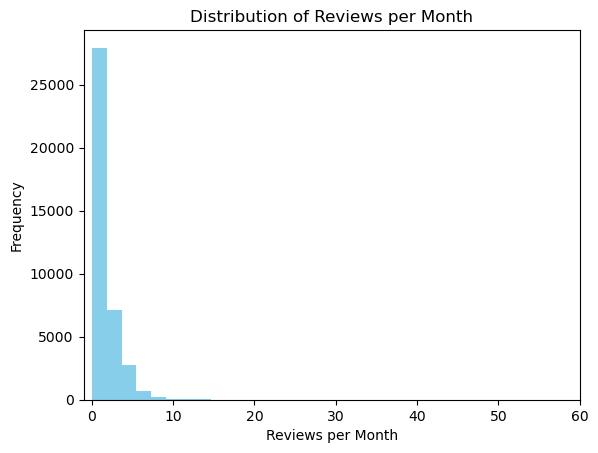

In [27]:
plt.hist(df['reviews_per_month'].dropna(),bins=32, color = 'skyblue')
plt.xlabel("Reviews per Month")
plt.ylabel("Frequency")
plt.title("Distribution of Reviews per Month")
plt.xlim(-1,60)
plt.show()

### Key observations and next steps

**Column Overview**

Looking at the dataset columns, they can be grouped into several categories based on their role in the dataset.

- Identifiers (unique or descriptive identifiers for listings or hosts):
`id`, `name`, `host_id`, `host_name`

- Numeric variables:
`latitude`, `longitude`, `price`, `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`, `availability_365`

- Categorical variables:
`neighbourhood_group`, `neighbourhood`, `room_type`, 

- Date variable:
`last_review`

- Target variable (prediction target):
`reviews_per_month`

**Missing values:**

Most columns in the dataset do not contain missing values. The columns `name` and `host_name` have only 16 and 21 missing entries respectively, which is less than 0.05% of the dataset and therefore unlikely to significantly affect the analysis. In contrast, `last_review` and `reviews_per_month` each contain 10,052 missing values. The identical number of missing entries suggests that these may correspond to listings that have never received reviews. Since `reviews_per_month` will be used as the target variable in this project, handling these missing values will be an important step in the data preparation stage.

**target vaiable**

The distribution of `reviews_per_month` is highly skewed, with many listings receiving fewer than 10 reviews per month and a small tail extending to much higher values, with a maximum of 58 reviews per month. A significant number of observations are missing, which likely corresponds to listings that have not yet received reviews. This distribution suggests that listing popularity varies widely across the dataset.

**Next steps**

In the next notebook, the dataset will be cleaned by addressing missing values, examining potential outliers, and preparing variables for exploratory data analysis and modeling.
